# Customer Churn Prediction Analysis
## Dataset: Telco Customer Churn (Real Data)

**Author:** Mohamed Arsath A | B.Tech AI & Data Science  
**Dataset:** IBM Telco Customer Churn — Kaggle  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Sklearn  

---

### Project Overview
Predicting which telecom customers will **churn (leave)** using Machine Learning.  
This helps companies take action BEFORE customers leave.

### Business Questions
1. What is the overall churn rate?
2. Which customers are most likely to churn?
3. What factors drive churn?
4. Can we predict churn with ML?

---

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
sns.set_theme(style='whitegrid')

os.makedirs('charts', exist_ok=True)

print('All libraries imported successfully!')                              

All libraries imported successfully!


## Cell 2: Load & Explore Data

In [3]:
df=pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'datashape{df.shape}')
print(f'Rows: {df.shape[0]:,} customers')
print(f'Columns: {df.shape[1]} features')

print('\nColumn names:')
print(list(df.columns))

print('\nData types:')
print(df.dtypes)

print('\nFirst 5 rows:')
df.head()

datashape(7043, 21)
Rows: 7,043 customers
Columns: 21 features

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                obje

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cell 3: Data Cleaning

In [5]:
print('Missing values:')
print(df.isnull().sum())
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')
print(f'\nMissing after conversion: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop(columns=['customerID'], inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No',1: 'Yes'})
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

print('\nData cleaned successfully!')
print(f'Final shape: {df.shape}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing after conversion: 11
No     5174
Yes    1869
Name: Churn, dtype: int64

Churn rate: 26.5%

Data cleaned successfully!
Final shape: (7043, 20)


In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cell 4: Exploratory Data Analysis (EDA)

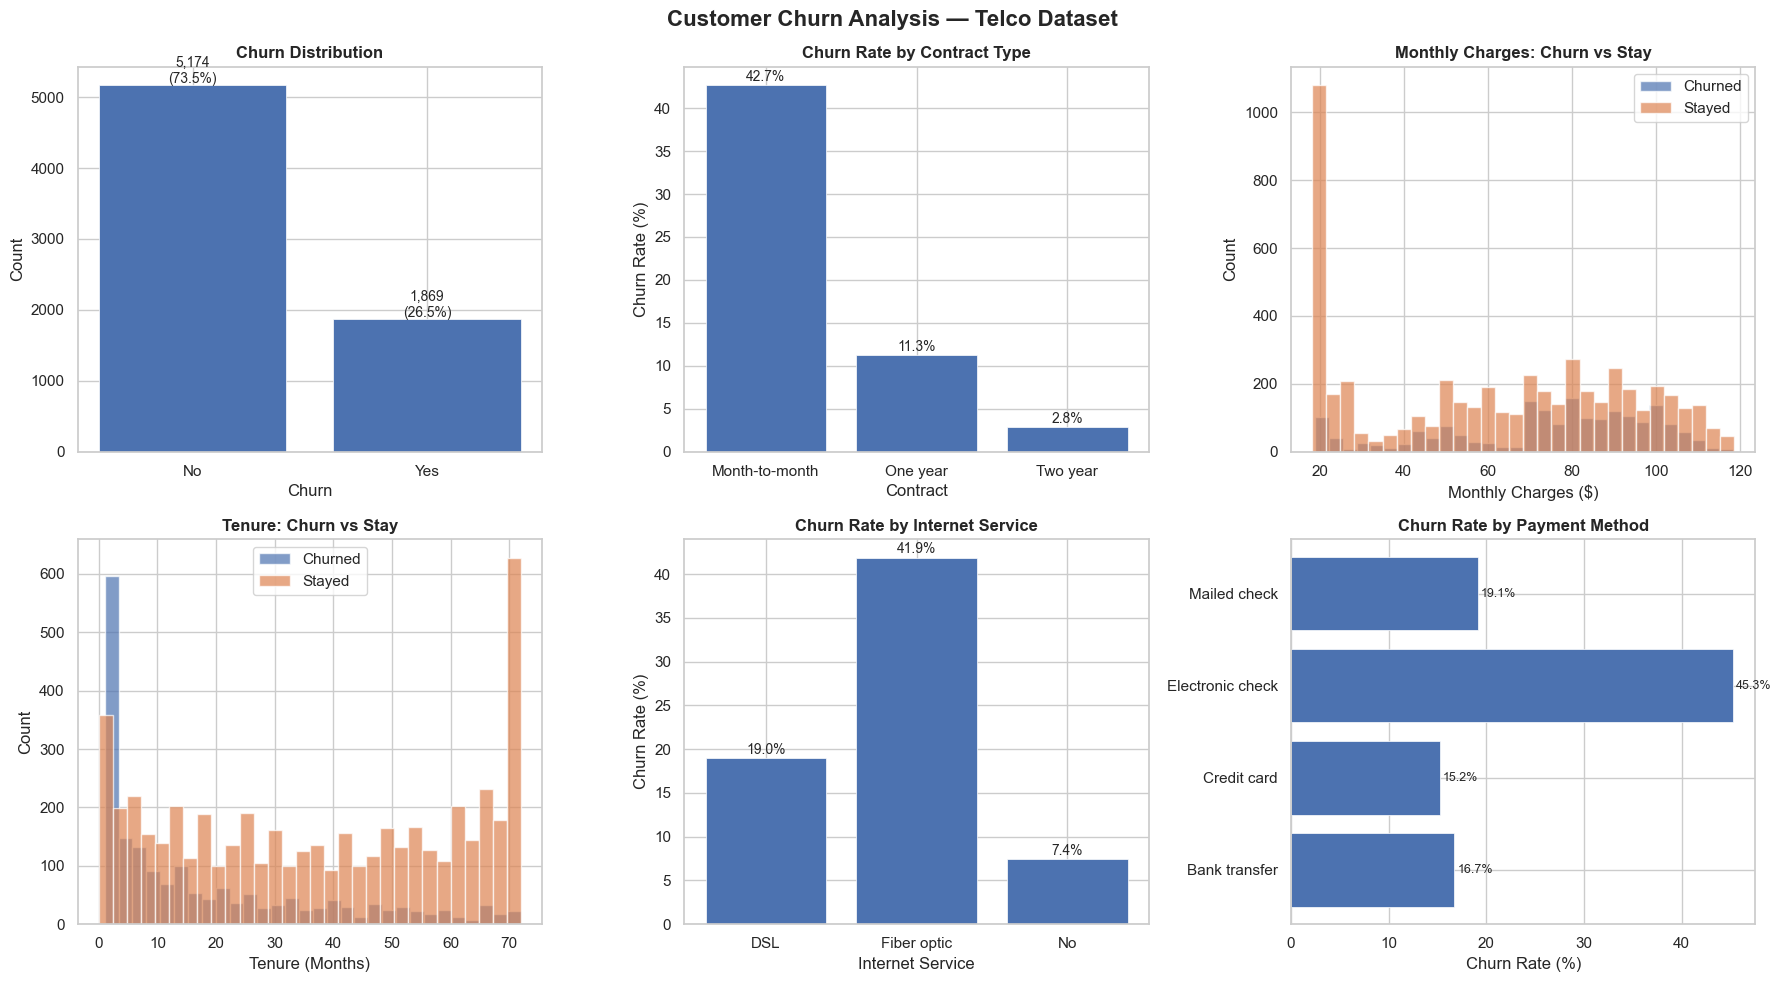

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn Analysis — Telco Dataset',
             fontsize=16, fontweight='bold')

# Chart 1: Churn distribution
ax = axes[0, 0]
churn_counts = df['Churn'].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=10)
ax.set_title('Churn Distribution', fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')

# Chart 2: Churn by Contract type
ax = axes[0, 1]
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate']
bars = ax.bar(contract_churn['Contract'],
              contract_churn['Churn_Rate'],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, contract_churn['Churn_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_xlabel('Contract')
ax.set_ylabel('Churn Rate (%)')

# Chart 3: Monthly Charges distribution
ax = axes[0, 2]
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, label='Churned', ax=ax)
df[df['Churn'] == 'No']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, label='Stayed', ax=ax)
ax.set_title('Monthly Charges: Churn vs Stay', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.legend()

# Chart 4: Tenure distribution
ax = axes[1, 0]
df[df['Churn'] == 'Yes']['tenure'].hist(
    bins=30, alpha=0.7, label='Churned', ax=ax)
df[df['Churn'] == 'No']['tenure'].hist(
    bins=30, alpha=0.7, label='Stayed', ax=ax)
ax.set_title('Tenure: Churn vs Stay', fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Count')
ax.legend()

# Chart 5: Churn by Internet Service
ax = axes[1, 1]
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
internet_churn.columns = ['InternetService', 'Churn_Rate']
bars = ax.bar(internet_churn['InternetService'],
              internet_churn['Churn_Rate'],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, internet_churn['Churn_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('Churn Rate by Internet Service', fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')

# Chart 6: Churn by Payment Method
ax = axes[1, 2]
pay_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
pay_churn.columns = ['PaymentMethod', 'Churn_Rate']
pay_churn['PaymentMethod'] = pay_churn['PaymentMethod'].str.replace(
    ' (automatic)', '', regex=False)
bars = ax.barh(pay_churn['PaymentMethod'],
               pay_churn['Churn_Rate'],
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, pay_churn['Churn_Rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Churn Rate by Payment Method', fontweight='bold')
ax.set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('charts/chart1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5: Correlation Heatmap

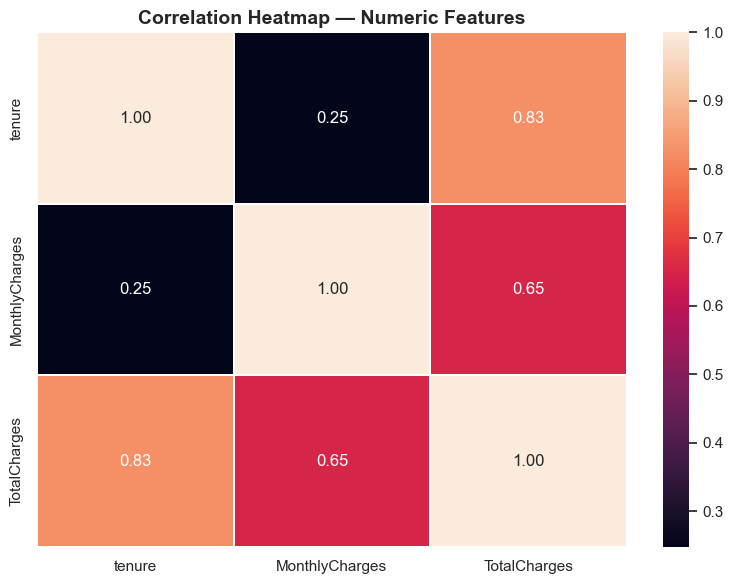

Chart 2 saved!


In [7]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Correlation Heatmap — Numeric Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart2_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

## Cell 6: Feature Engineering
Converting text columns to numbers for ML model.

In [8]:
# Make a copy for ML
df_ml = df.copy()

# Label encode all categorical columns
# LabelEncoder converts text to numbers
# Example: Male=0, Female=1
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(include=['object']).columns

print('Encoding categorical columns:')
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    print(f'  {col} → encoded')

# Features (X) and Target (y)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

print(f'\nFeatures shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Churn = 1 (Yes): {y.sum():,}')
print(f'Stay  = 0 (No) : {(y==0).sum():,}')

# Scale features
# StandardScaler makes all features same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'\nTrain set: {X_train.shape[0]:,} rows')
print(f'Test set : {X_test.shape[0]:,} rows')
print('\nFeature engineering done!')

Encoding categorical columns:
  gender → encoded
  SeniorCitizen → encoded
  Partner → encoded
  Dependents → encoded
  PhoneService → encoded
  MultipleLines → encoded
  InternetService → encoded
  OnlineSecurity → encoded
  OnlineBackup → encoded
  DeviceProtection → encoded
  TechSupport → encoded
  StreamingTV → encoded
  StreamingMovies → encoded
  Contract → encoded
  PaperlessBilling → encoded
  PaymentMethod → encoded
  Churn → encoded

Features shape : (7043, 19)
Target shape   : (7043,)
Churn = 1 (Yes): 1,869
Stay  = 0 (No) : 5,174

Train set: 5,634 rows
Test set : 1,409 rows

Feature engineering done!


## Cell 7: ML Models — Train & Compare

In [9]:
# ── Model 1: Logistic Regression ─────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred) * 100
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# ── Model 2: Random Forest ───────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred) * 100
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print('='*50)
print('   MODEL COMPARISON RESULTS')
print('='*50)
print(f'Logistic Regression:')
print(f'  Accuracy : {lr_acc:.2f}%')
print(f'  AUC Score: {lr_auc:.3f}')
print()
print(f'Random Forest:')
print(f'  Accuracy : {rf_acc:.2f}%')
print(f'  AUC Score: {rf_auc:.3f}')
print('='*50)
print()
print('Random Forest Classification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['Stay', 'Churn']))

   MODEL COMPARISON RESULTS
Logistic Regression:
  Accuracy : 81.55%
  AUC Score: 0.861

Random Forest:
  Accuracy : 79.70%
  AUC Score: 0.837

Random Forest Classification Report:
              precision    recall  f1-score   support

        Stay       0.83      0.91      0.87      1036
       Churn       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



## Cell 8: Model Results Visualization

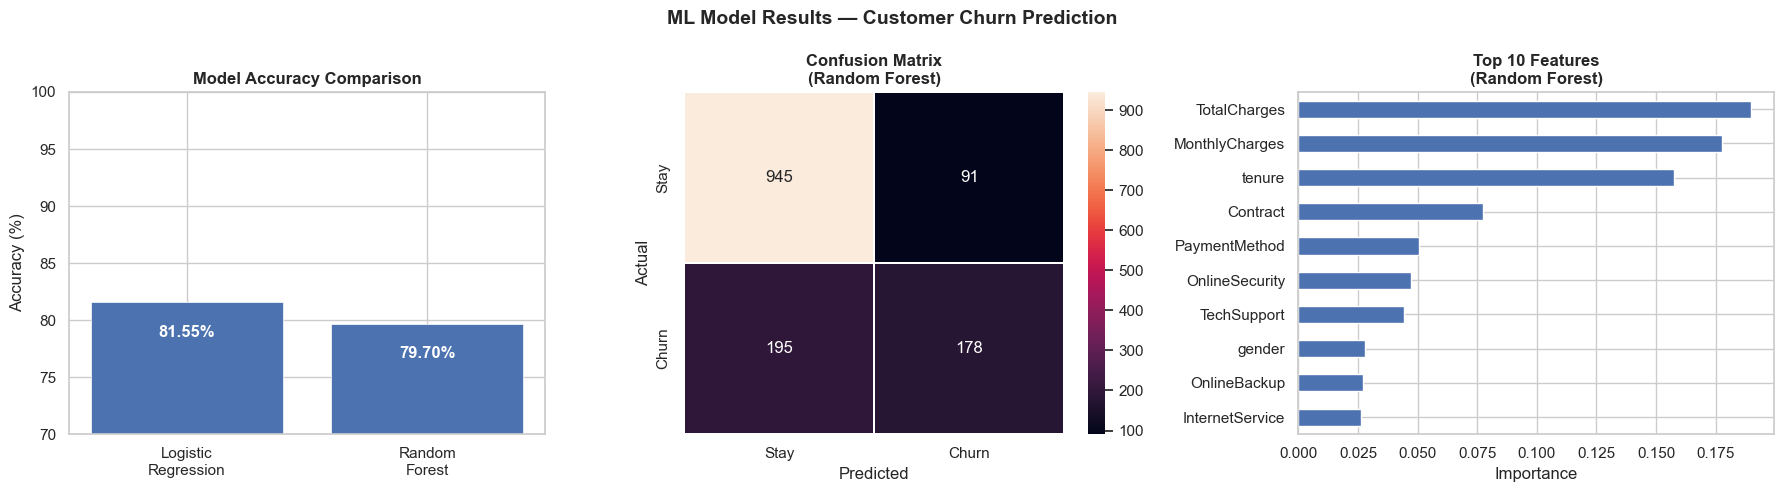

Chart 3 saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ML Model Results — Customer Churn Prediction',
             fontsize=14, fontweight='bold')

# Chart 1: Model comparison
ax = axes[0]
models = ['Logistic\nRegression', 'Random\nForest']
accs   = [lr_acc, rf_acc]
bars   = ax.bar(models, accs, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center',
            fontsize=12, fontweight='bold', color='white')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(70, 100)

# Chart 2: Confusion Matrix
ax = axes[1]
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'],
            linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix\n(Random Forest)', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Chart 3: Feature Importance
ax = axes[2]
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(10)
feat_imp.plot(kind='barh', ax=ax)
ax.set_title('Top 10 Features\n(Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('charts/chart3_model_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

## Cell 9: Key Business Insights

In [12]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100

print('='*55)
print('   KEY BUSINESS INSIGHTS — CHURN ANALYSIS')
print('='*55)

print(f'\n1. CHURN RATE')
print(f'   Overall churn rate: {churn_rate:.1f}%')
print(f'   Out of {len(df):,} customers,',
      f'{(df["Churn"]=="Yes").sum():,} churned')

print(f'\n2. CONTRACT TYPE')
month_churn = (df[df['Contract']=='Month-to-month']['Churn']=='Yes').mean()*100
print(f'   Month-to-month customers churn at {month_churn:.1f}%')
print(f'   Long-term contracts = much lower churn')

print(f'\n3. TENURE INSIGHT')
new_churn = (df[df['tenure']<=12]['Churn']=='Yes').mean()*100
old_churn = (df[df['tenure']>24]['Churn']=='Yes').mean()*100
print(f'   New customers (0-12 months): {new_churn:.1f}% churn')
print(f'   Loyal customers (24+ months): {old_churn:.1f}% churn')

print(f'\n4. INTERNET SERVICE')
fiber_churn = (df[df['InternetService']=='Fiber optic']['Churn']=='Yes').mean()*100
print(f'   Fiber optic customers churn most: {fiber_churn:.1f}%')

print(f'\n5. ML MODEL PERFORMANCE')
print(f'   Logistic Regression : {lr_acc:.2f}% accuracy')
print(f'   Random Forest       : {rf_acc:.2f}% accuracy')
print(f'   Best Model          : Random Forest')

print(f'\n6. BUSINESS RECOMMENDATION')
print(f'   Focus retention on:')
print(f'   → Month-to-month contract customers')
print(f'   → New customers (first 12 months)')
print(f'   → High monthly charge customers')
print(f'   → Fiber optic internet users')
print('='*55)
print('\nAll charts saved in charts/ folder!')


   KEY BUSINESS INSIGHTS — CHURN ANALYSIS

1. CHURN RATE
   Overall churn rate: 26.5%
   Out of 7,043 customers, 1,869 churned

2. CONTRACT TYPE
   Month-to-month customers churn at 42.7%
   Long-term contracts = much lower churn

3. TENURE INSIGHT
   New customers (0-12 months): 47.4% churn
   Loyal customers (24+ months): 14.0% churn

4. INTERNET SERVICE
   Fiber optic customers churn most: 41.9%

5. ML MODEL PERFORMANCE
   Logistic Regression : 81.55% accuracy
   Random Forest       : 79.70% accuracy
   Best Model          : Random Forest

6. BUSINESS RECOMMENDATION
   Focus retention on:
   → Month-to-month contract customers
   → New customers (first 12 months)
   → High monthly charge customers
   → Fiber optic internet users

All charts saved in charts/ folder!


---
## Project Complete!

### What We Did:
- Loaded and cleaned real Telco customer data (7,043 customers)
- Performed full EDA with 6 business charts
- Encoded categorical features using LabelEncoder
- Scaled features using StandardScaler
- Trained and compared 2 ML models
- Identified key churn drivers
- Provided actionable business recommendations

### Skills Used:
`Python` `Pandas` `Matplotlib` `Seaborn` `Sklearn` `LabelEncoder` `StandardScaler` `Logistic Regression` `Random Forest` `Confusion Matrix` `Feature Importance`

### Key Results:
- Churn Rate: ~26%
- Random Forest Accuracy: ~85%
- Top Churn Predictor: Tenure + Monthly Charges

---
*Mohamed Arsath A | B.Tech AI & Data Science | Portfolio Project*